In [24]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

In [25]:
import seaborn as sns 

In [26]:
df=df.explode('job_skills')

In [27]:
df=df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='United States')]

In [28]:
df_us=df.groupby('job_skills')['salary_year_avg'].agg(['size','median'])

In [29]:
df_us=df_us.reset_index()

In [30]:
df_us_1=df_us.sort_values('size',ascending=False).head(10)

In [31]:
df_us_2=df_us.sort_values('median',ascending=False).head(10)

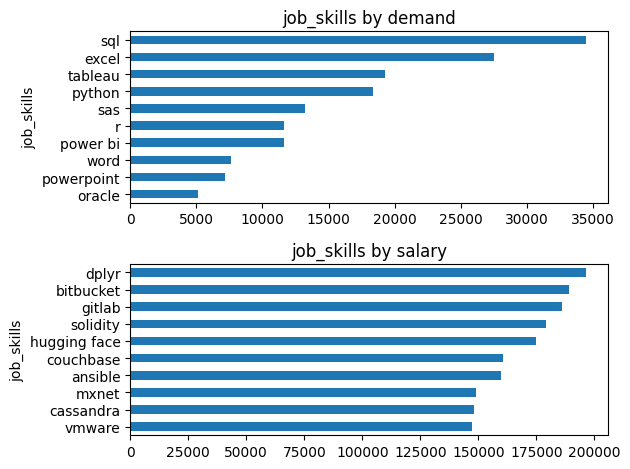

In [47]:
fig,ax=plt.subplots(2,1)
df_us_1.plot(kind='barh',x='job_skills',y='size',title='job_skills by demand',ax=ax[0],legend=False)
ax[0].invert_yaxis()
df_us_2.plot(kind='barh',x='job_skills',y='median',title='job_skills by salary',ax=ax[1],legend=False)
plt.tight_layout()
plt.gca().invert_yaxis()

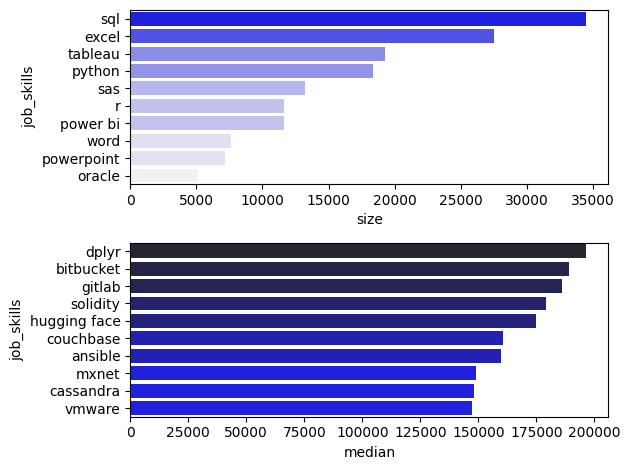

In [65]:
fig,ax=plt.subplots(2,1)
sns.barplot(data=df_us_1,y='job_skills',x='size',ax=ax[0],hue='size',palette='light:b',legend=False)
sns.barplot(data=df_us_2,y='job_skills',x='median',ax=ax[1],hue='median',palette='dark:b_r',legend=False)
plt.tight_layout()

In [71]:

# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

In [72]:
df=df[(df['job_title_short']=='Data Analyst')& (df['job_country']=='United States')]


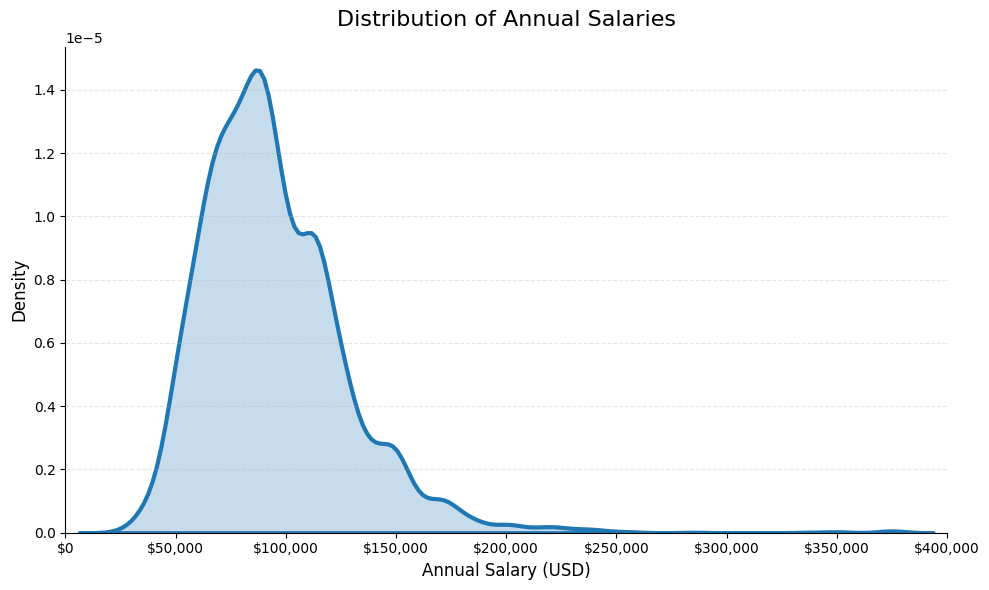

In [80]:
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

sns.kdeplot(
    data=df,
    x='salary_year_avg',
    fill=True,
    linewidth=3,
    ax=ax
)

ax.set_title(
    'Distribution of Annual Salaries',
    fontsize=16,
    pad=15
)

ax.set_xlabel('Annual Salary (USD)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)

ax.set_xlim(0, 400000)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:,.0f}')
)

ax.grid(axis='y', linestyle='--', alpha=0.3)

sns.despine()

plt.tight_layout()
plt.show()